In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import numpy as np
import pandas as pd
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    _hopping_matrix,
)
from alter_morph.lattice_utilities import alter_lattice_maker
from alter_morph.hamiltonians import _hopping_matrix
from alter_morph.mean_field import hartree_fock, single_hartree_fock_step

from tqdm import tqdm
import seaborn as sns

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [81]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )

In [82]:
# make the lattice
system_length = 4
lattice_type = "honeycomb"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)
print(lattice)

Lattice(24 vertices, 36 edges)


In [83]:
_hopping_matrix(1, 1, np.pi / 3)

array([[-1., -0.],
       [-0., -1.]])

In [ ]:
# make the parameters_to_sweep
def parameters(sweep_value):
    t1 = 1
    t2 = 0.5
    J = 0.4
    U = J
    filling = np.interp(sweep_value, [0, 1], [0.01, 0.99])
    initial_m = np.full(lattice.n_vertices, 1)
    initial_n = np.full(lattice.n_vertices, filling * 4)
    theta_offset = 0.0

    return {
        "t1": t1,
        "t2": t2,
        "J": J,
        "U": U,
        "filling": filling,
        "initial_m": initial_m,
        "initial_n": initial_n,
        "theta_offset": theta_offset,
    }

In [85]:
resolution = 100
x_in = np.linspace(0, 1, resolution)

In [86]:
def perform_parameter_sweep(parameters, x_in):
    m_out = []
    n_out = []
    e_out = []
    s_out = []
    fermi_out = []
    how_well_converged = []

    x_in = np.linspace(0, 1, resolution)
    for i in tqdm(x_in):
        params = parameters(i)
        if i != 0:
            params["initial_m"] = m_out[-1]
            params["initial_n"] = n_out[-1]

        m_values, n_values = hartree_fock(
            lattice,
            params,
            1000,
            mixing_proportion=0.1,
            tol_mdiff=0.0005,
            verbose=False,
            leave=True,
            adjust_learning_rate=True,
        )
        # plt.plot(m_values)
        # plt.show()

        hamiltonian = alt_hamiltonian(
            lattice,
            params["t1"],
            params["t2"],
            params["J"],
            params["U"],
            m_values[-1],
            n_values[-1],
            theta_offset=params["theta_offset"],
        )
        energies, states = la.eigh(hamiltonian)

        how_well_converged.append(len(m_values))

        current_m = m_values[-1] + np.random.normal(0, 0.01, lattice.n_vertices)
        current_n = n_values[-1] + np.random.normal(0, 0.01, lattice.n_vertices)

        fermi_out.append(fermi_level(energies, params["filling"]))
        m_out.append(current_m)
        n_out.append(current_n)
        e_out.append(energies)
        s_out.append(states)

    return m_out, n_out, e_out, s_out, fermi_out, how_well_converged


m_out, n_out, e_out, s_out, fermi_out, how_well_converged = perform_parameter_sweep(
    parameters, x_in
)

  0%|          | 0/100 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/physics/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/physics/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 100/100 [00:32<00:00,  3.05it/s]


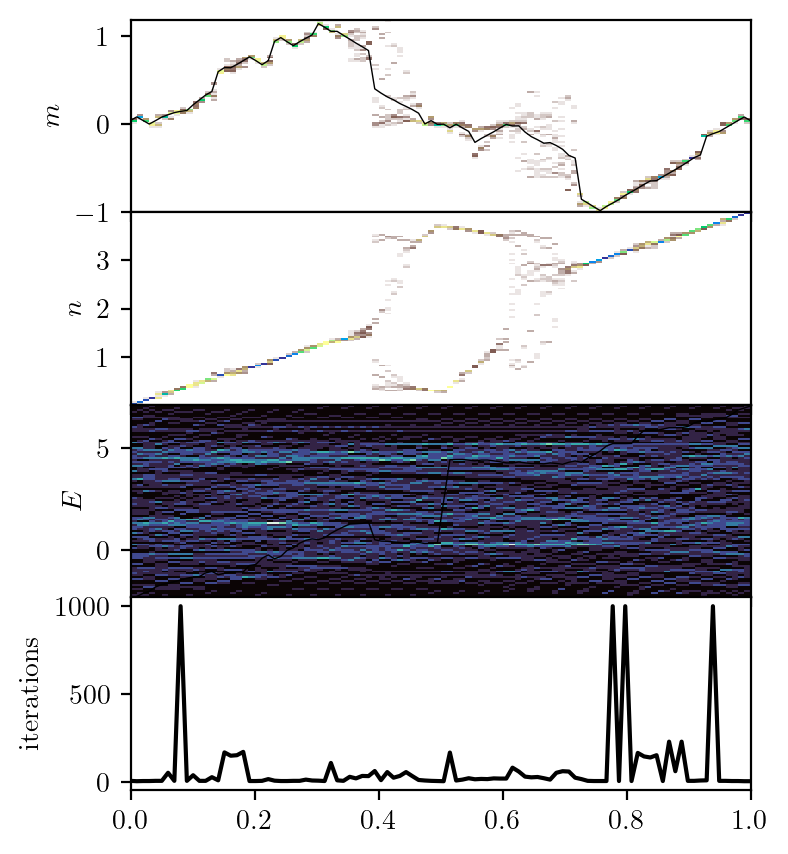

In [87]:
fig, ax = plt.subplots(4, 1, figsize=(4, 5), sharex=True, dpi=200)

fig.subplots_adjust(hspace=0)


ax[0].hist2d(
    np.tile(x_in, (lattice.n_vertices, 1)).T.flatten(),
    np.array(m_out).flatten(),
    bins=100,
    cmap="terrain_r",
)
ax[0].plot(x_in, np.mean(m_out, axis=1), color="black", linewidth=0.5)

ax[0].set_ylabel("$m$")


ax[1].hist2d(
    np.tile(x_in, (lattice.n_vertices, 1)).T.flatten(),
    np.array(n_out).flatten(),
    bins=100,
    cmap="terrain_r",
)

ax[1].set_ylabel("$n$")


ax[2].hist2d(
    np.tile(x_in, (lattice.n_vertices * 4,)).T.flatten(),
    np.array(e_out).flatten(),
    bins=100,
    cmap="mako",
)
ax[2].plot(x_in, fermi_out, color="black", linewidth=0.5)

ax[2].set_ylabel("$E$")

ax[3].plot(x_in, how_well_converged, color="black")


ax[3].set_ylabel("iterations")

plt.show()

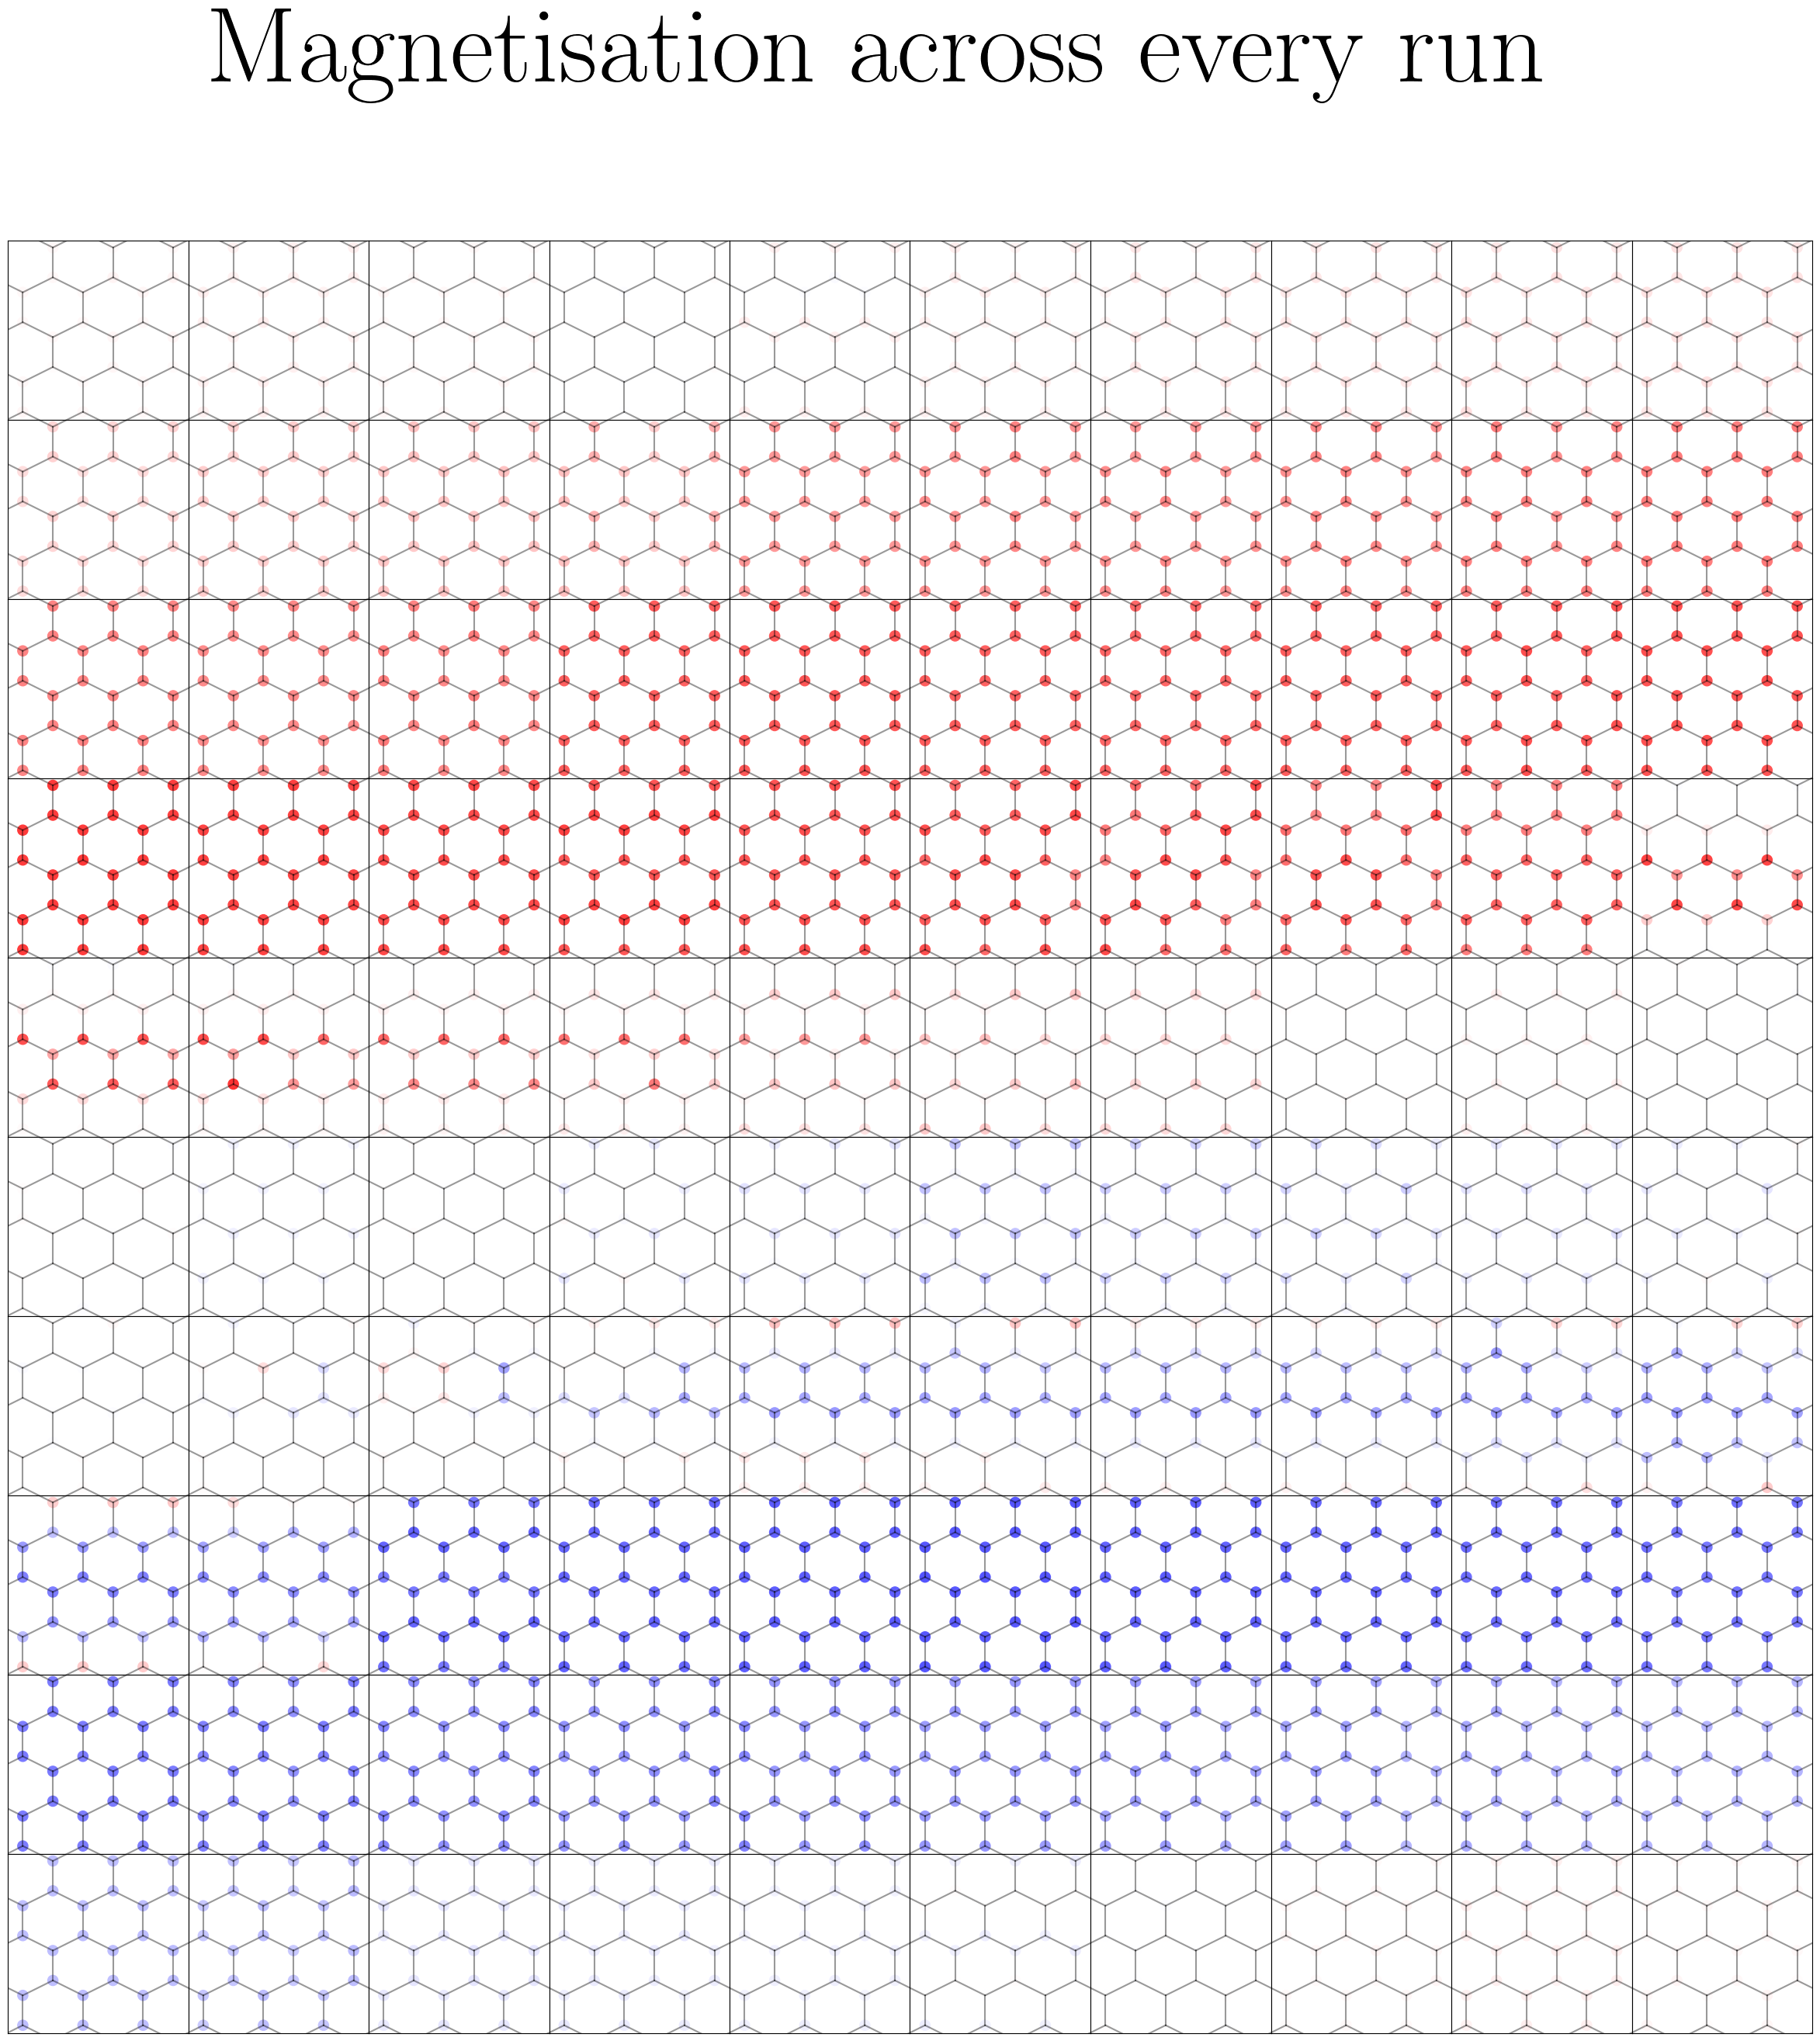

In [88]:
fig, ax = plt.subplots(resolution // 10, 10, figsize=(30, 3 * (resolution // 10)))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
ax = ax.flatten()
# m_out = np.array(m_out)[::-1]

pos = lattice.vertices.positions
# copy four times for pb
n_sites = lattice.n_vertices
shifty = (
    [[0, 0]] * n_sites
    + [[0, 1]] * n_sites
    + [[1, 0]] * n_sites
    + [[0, -1]] * n_sites
    + [[-1, 0]] * n_sites
)
pos = np.concatenate([pos] * 5) + np.array(shifty)
site_mask = np.all(np.abs(pos - 0.5) < 0.6, axis=1)
pos = pos[site_mask]

for i in range(resolution):
    pl.plot_edges(lattice, ax=ax[i], alpha=0.4)
    im = ax[i].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.concatenate([m_out[i]] * 5)[site_mask],
        cmap="bwr",
        s=90,
        vmin=-1.5,
        vmax=1.5,
        zorder=-2,
    )
    # get rid of the axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # remove axes
    # ax[i].axis("off")

# overall title
fig.suptitle("Magnetisation across every run", fontsize=100)

plt.show()

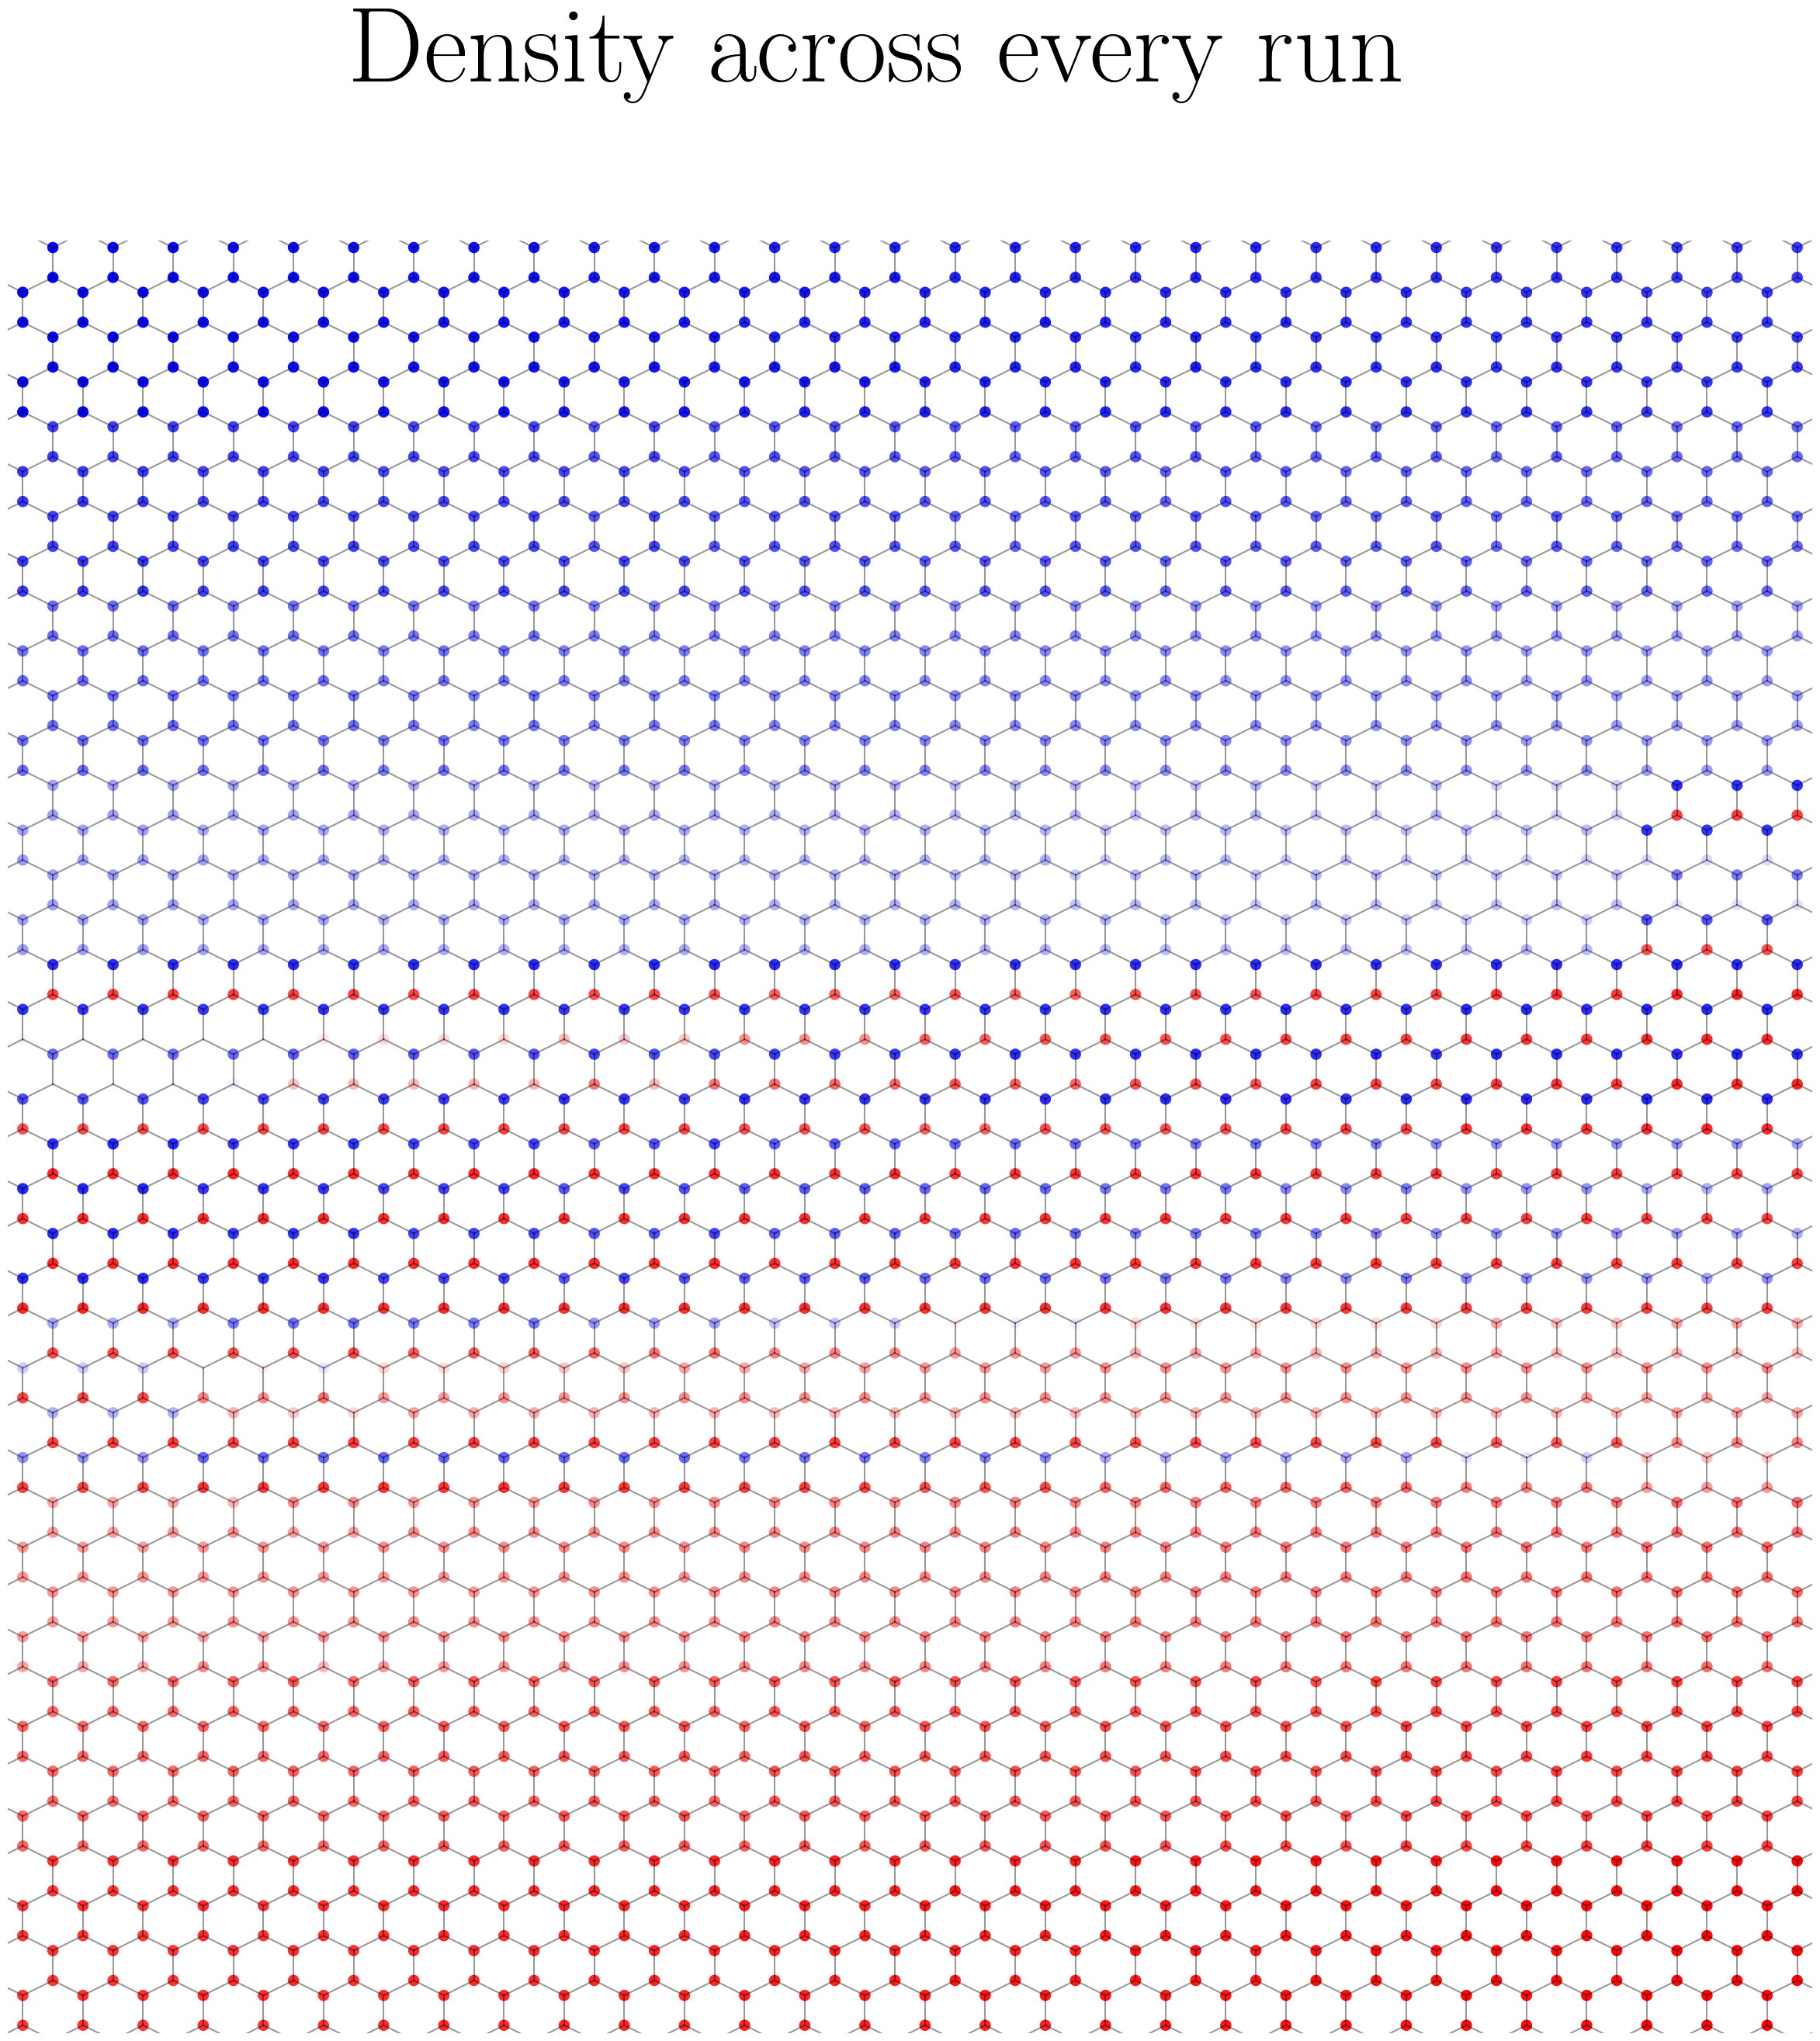

In [89]:
fig, ax = plt.subplots(resolution // 10, 10, figsize=(30, 3 * (resolution // 10)))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
ax = ax.flatten()
# m_out = np.array(m_out)[::-1]

pos = lattice.vertices.positions
# copy four times for pb
n_sites = lattice.n_vertices
shifty = (
    [[0, 0]] * n_sites
    + [[0, 1]] * n_sites
    + [[1, 0]] * n_sites
    + [[0, -1]] * n_sites
    + [[-1, 0]] * n_sites
)
pos = np.concatenate([pos] * 5) + np.array(shifty)
site_mask = np.all(np.abs(pos - 0.5) < 0.6, axis=1)
pos = pos[site_mask]

for i in range(resolution):
    pl.plot_edges(lattice, ax=ax[i], alpha=0.4)
    im = ax[i].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.concatenate([n_out[i]] * 5)[site_mask],
        cmap="bwr",
        s=90,
        vmin=0,
        vmax=4,
        zorder=-2,
    )
    # get rid of the axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # remove axes
    ax[i].axis("off")

# overall title
fig.suptitle("Density across every run", fontsize=100)

plt.show()